## Eval 2

The goal of this evaluation is to solve six optimization problem (whose oracles are given) using the algorithms you have seen so far in the practical sessions. You can freely re-use your notes and implemented algorithms from the previous practical sessions. 

When working on problem number $i$, you should:
- look into the file `problemi.py` to observe the properties of the problem at hand, 
- select which algorithm is, in your opinion, best suited for this problem based on these properties,
- justify this choice,
- run the algorithm,
- comment on the observed performance.

Initialise the algorithms from $x_0 = 0$. If for some reason, you need an alternative initialization, explain why this is the case and include the run initialized at $x_0 = 0$. You can only use the provided oracles `f` and `grad_f`, and you may have to implement additional projection and proximity operators. If you perform some pen-and-paper calculations, you do not have to write down all the details in the notebook: just explain what you were trying to compute, how you computed it, and the result you obtained. The choice of hyper-parameters (stopping criterion, step-size,...) is up to you and should be justified.

At the end of the session (i.e., before 11:15), send me an email to `thomas.guilmeau@inria.fr` with object `NumOpt - eval2 - yourFirstName_yourSurname` with an attached archive named `yourFirstName_yourSurname` containing this notebook with your explainations and runs, the problem files, the `utils.py` file, as well as the `algorithms.py` files that you have used. I should be able to run your notebook again and obtain the same results as you.

*Some advice:*

If you realise that maybe another algorithm is a better choice, or if you think that two algorithms may have similar performance, you can explain why you think so, run both algorithms, and compare their performance. Some problems are harder than others, so if you do not manage to solve exactly the problem, you can explain why the algorithms you have considered do not work and move on to the next problems.

In [ ]:
import sys
from utils import *
from algorithms import *


### Problem 1

Minimize the quadratic function defined by $f(x) = \frac{1}{2}x^\top A x + b^\top x + c$ where $A \succ 0$, $b \in \mathbb{R}^d$, and $c \in \mathbb{R}$ using only the noisy oracle `grad_f`, which returns 
$$
\nabla f(x) + n
$$
for every $x \in \mathbb{R}^d$. Here, $n$ is distributed following a standard Gaussian distribution. Yo uare also given an exact oracle `f` of $f$.

For this problem, you can only use a maximum number of $K = 250$ iterations.

------------------------------------
 Stochastic gradient descent 
------------------------------------
START
FINISHED -- 249 iterations -- 0.012090s -- final value: 195.825862


tau = 0.005 f(last) = 13.229985877645959 f(avg) = 195.8258623645088
------------------------------------
 Stochastic gradient descent 
------------------------------------
START
FINISHED -- 249 iterations -- 0.013120s -- final value: 88.103495


tau = 0.008 f(last) = 2.0752877166160033 f(avg) = 88.10349511725508
------------------------------------
 Stochastic gradient descent 
------------------------------------
START
FINISHED -- 249 iterations -- 0.013760s -- final value: 58.540719


tau = 0.01 f(last) = 0.86013558342529 f(avg) = 58.54071892617503
------------------------------------
 Stochastic gradient descent 
------------------------------------
START
FINISHED -- 249 iterations -- 0.012400s -- final value: 41.456715


tau = 0.012 f(last) = 0.5597715401745518 f(avg) = 41.45671520081669
------------------

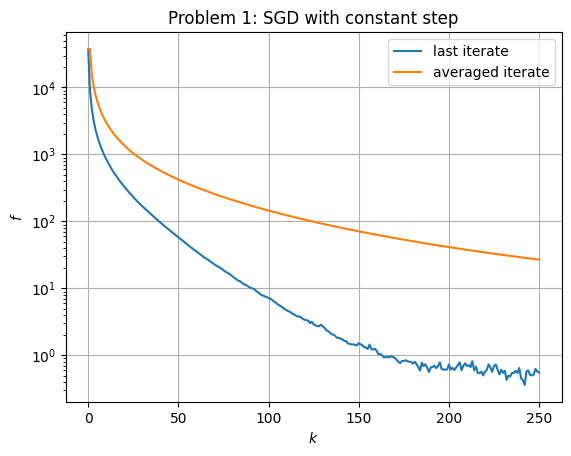

In [81]:
np.random.seed(0)
from problem1 import *

K = 250
x_init = np.zeros(d)
taus = [0.005, 0.008, 0.01, 0.012, 0.015]
best = None

for tau in taus:
    np.random.seed(0)
    x, x_tab, x_avg, x_avg_tab = SGD(f, grad_f, x_init, tau, 'constant', K)
    val = f(x)
    print('tau =', tau, 'f(last) =', val, 'f(avg) =', f(x_avg))
    if best is None or val < best[0]:
        best = (val, tau, x, x_tab, x_avg, x_avg_tab)

_, tau, x, x_tab, x_avg, x_avg_tab = best
print('selected tau =', tau)
print('f(last) =', f(x))
print('f(avg) =', f(x_avg))

plt.figure()
plt.semilogy([f(u) for u in x_tab], label='last iterate')
plt.semilogy([f(u) for u in x_avg_tab], label='averaged iterate')
plt.xlabel(r'$k$')
plt.ylabel(r'$f$')
plt.title(r'Problem 1: SGD with constant step')
plt.grid(True)
plt.legend()
plt.show()

In this problem, the gradient is $\nabla f(x)=Ax+b$, so the smoothness and strong convexity constants are given by the extremal eigenvalues of $A$: $L=\lambda_{\max}(A)$ and $\mu=\lambda_{\min}(A)$. Here $A=YDY$ with $Y$ orthogonal and $D$ diagonal with entries going from $1$ to $\kappa$. Therefore the spectrum of $A$ is exactly the diagonal of $D$, hence $\mu=1$ and $L=\kappa=100$.

For deterministic GD, a safe step is $1/L=0.01$ and stability requires $0<\tau<2/L=0.02$. Since the oracle is stochastic, we still use this as the right scale, but with a smaller practical step to control the noise. 

### Problem 1 bis

Consider again the optimization problem given in Problem 1, but this time, you can only use a maximum number of $K = 3000$ iterations.

------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 2999 iterations -- 1.403538s -- final value: 31.986250


tau = 0.001 f(last) = 0.14993151921225945 f(avg) = 31.98625015993457
------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 2999 iterations -- 0.563928s -- final value: 8.178536


tau = 0.002 f(last) = 0.04948717964725802 f(avg) = 8.178536138657364
------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 2999 iterations -- 0.490726s -- final value: 3.642741


tau = 0.003 f(last) = 0.07170828536618501 f(avg) = 3.6427413531928323
------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 2999 iterations -- 0.453979s -- final value: 1.316490


tau = 0.005 f(last) = 0.1193687747218064 f(avg) = 1.3164901522395667
selected tau = 0.002
f(last) = 0.04948717964725802
f(avg) = 8.178536138657364


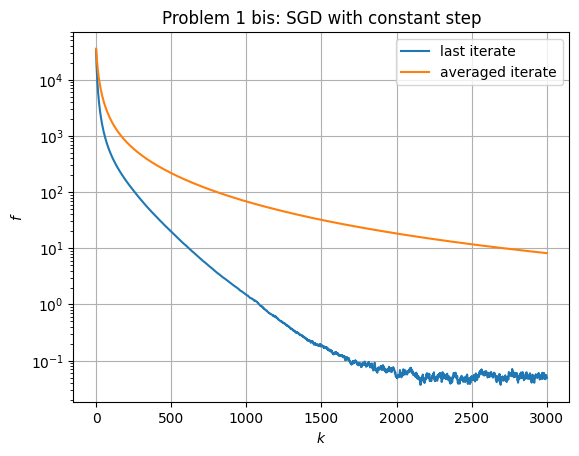

In [3]:
np.random.seed(0)
from problem1 import *

K = 3000
x_init = np.zeros(d)
taus = [0.001, 0.002, 0.003, 0.005]
best = None

for tau in taus:
    np.random.seed(0)
    x, x_tab, x_avg, x_avg_tab = SGD(f, grad_f, x_init, tau, 'constant', K)
    val = f(x)
    print('tau =', tau, 'f(last) =', val, 'f(avg) =', f(x_avg))
    if best is None or val < best[0]:
        best = (val, tau, x, x_tab, x_avg, x_avg_tab)

_, tau, x, x_tab, x_avg, x_avg_tab = best
print('selected tau =', tau)
print('f(last) =', f(x))
print('f(avg) =', f(x_avg))

plt.figure()
plt.semilogy([f(u) for u in x_tab], label='last iterate')
plt.semilogy([f(u) for u in x_avg_tab], label='averaged iterate')
plt.xlabel(r'$k$')
plt.ylabel(r'$f$')
plt.title(r'Problem 1 bis: SGD with constant step')
plt.grid(True)
plt.legend()
plt.show()

With more allowed iterations, we keep standard SGD but we allow ourselves to lower the step to reduce the stochastic error floor.

### Problem 1 ter

Consider again the optimization problem given in Problem 1, but this time, you can only use a maximum number of $K = 10000$ iterations.

------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 9999 iterations -- 27.111952s -- final value: 0.120853


tau = 0.005 f(last) = 0.13277835854387376 f(avg) = 0.1208533667595475
------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 9999 iterations -- 12.455609s -- final value: 0.048340


tau = 0.008 f(last) = 0.2381359702485497 f(avg) = 0.048339809669414535
------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 9999 iterations -- 8.147536s -- final value: 0.031503


tau = 0.01 f(last) = 0.31521165493904846 f(avg) = 0.03150344928872073
------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 9999 iterations -- 6.128625s -- final value: 0.022316


tau = 0.012 f(last) = 0.39781436661724 f(avg) = 0.02231644791754661
------------------------------------
 Stochastic gradient descent 
------------------------------------
START


FINISHED -- 9999 iterations -- 5.995364s -- final value: 0.014759


tau = 0.015 f(last) = 0.5386238617502386 f(avg) = 0.014759009594854433
selected tau = 0.015
f(last) = 0.5386238617502386
f(avg) = 0.014759009594854433


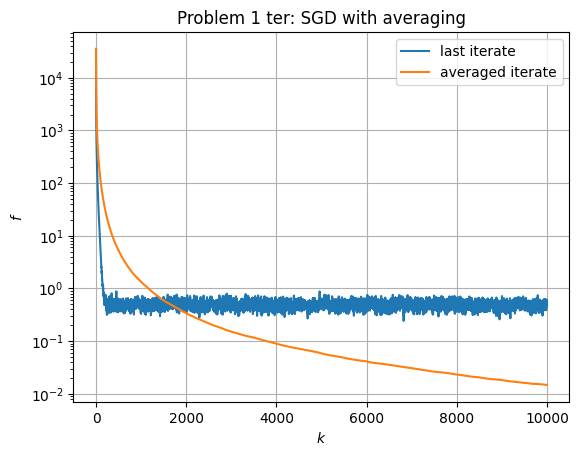

In [4]:
np.random.seed(0)
from problem1 import *

K = 10000
x_init = np.zeros(d)
taus = [0.005, 0.008, 0.01, 0.012, 0.015]
best = None

for tau in taus:
    np.random.seed(0)
    x, x_tab, x_avg, x_avg_tab = SGD(f, grad_f, x_init, tau, 'constant', K)
    val = f(x_avg)
    print('tau =', tau, 'f(last) =', f(x), 'f(avg) =', val)
    if best is None or val < best[0]:
        best = (val, tau, x, x_tab, x_avg, x_avg_tab)


_, tau, x, x_tab, x_avg, x_avg_tab = best
print('selected tau =', tau)
print('f(last) =', f(x))
print('f(avg) =', f(x_avg))

plt.figure()
plt.semilogy([f(u) for u in x_tab], label='last iterate')
plt.semilogy([f(u) for u in x_avg_tab], label='averaged iterate')
plt.xlabel(r'$k$')
plt.ylabel(r'$f$')
plt.title(r'Problem 1 ter: SGD with averaging')
plt.grid(True)
plt.legend()
plt.show()

With a higher budget, we can use the averaged iterate to select tau, which allows to go below the noise barrier the last iterate is blocked at.

### Problem 2

Minimize the function $f : \mathbb{R}^d \rightarrow \mathbb{R}$ over $\mathbb{R}^d$, using only the noisy oracle `grad_f` of $\nabla f$. For any $x \in \mathbb{R}^d$, this oracles returns
$$
\nabla f(x) + n,
$$
where $n$ follows a $d$-dimensional standard Student-t distribution with $2$ degrees f freedom (such a distribution is called *heavy-tailed*, and corresponds to a high-noise regime).

Here, the objective function $f$ is defined by
$$
f(x) = \log\left( 1 + \frac{1}{\nu}(x - \mu)^\top \Sigma^{-1}(x-\mu) \right)
$$
with $\nu > 0$, $\Sigma \succ 0$, and $\mu \in \mathbb{R}^d$, and you are also given an exact oracle of $f$.

initial value = 8.933247426278903
Adagrad-norm
------------------------------------
 Adagrad-norm 
------------------------------------
START
FINISHED -- 99999 iterations -- 73.748646s -- final value: 4.717032


tau = 8 f(x) = 4.717031825000705
selected tau = 8
final value = 4.717031825000705


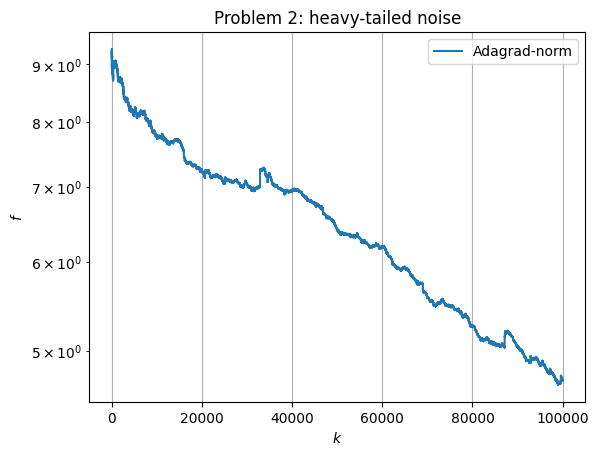

In [79]:
np.random.seed(0)
from problem2 import *

K = 100000
x_init = np.zeros(d)
taus = [8] # we run an expensive number of iterations thus keep only one value of tau. In practice, it doens't matter much since the algorithm is quite robust to the choice of tau.
best = None

print('initial value =', f(x_init))
print('Adagrad-norm')
for tau in taus:
    np.random.seed(0)
    x, x_tab = adagrad_norm(f, grad_f, x_init, tau, 1e-6, K)
    val = f(x)
    print('tau =', tau, 'f(x) =', val)
    if best is None or val < best[0]:
        best = (val, tau, x, x_tab)

_, tau, x, x_tab = best
print('selected tau =', tau)
print('final value =', f(x))

plt.figure()
plt.semilogy([f(u) for u in x_tab], label='Adagrad-norm')
plt.xlabel(r'$k$')
plt.ylabel(r'$f$')
plt.title(r'Problem 2: heavy-tailed noise')
plt.grid(True)
plt.legend()
plt.show()

We have $f(x) = \log ( 1+ \lVert x - \mu \rVert_{\sigma}^2)$, so the unique minimizer is $x_*=\mu$ and the minimum value is $0$. However, we are in a high noise regime so methods relying on accurate gradient differences are not appropriate here. We therefore test `adagrad_norm`, which is more robust to occasional very large stochastic gradients.

### Problem 3

Minimize $F = f + g$ on $\mathbb{R}^d$ where
\begin{align*}
    f(x) &= \sum_{i=1}^d f_i(x_i),\\
    g(x) &= \max \{ \|x\|_2 -\epsilon, 0 \}.
\end{align*}
For any $i \in \{1,\dots,d\}$, the function $f_i : \mathbb{R} \rightarrow \mathbb{R}$ is defined by
$$
f_i(x_i ) = \delta_i^2 \left(  \sqrt{1 + (x_i / \delta_i)^2} - 1 \right)
$$
where $\delta_i > 0$. Exact oracles for evaluating $f$, $g$, $F$, and $\nabla f$ are given.

The following formula is also given for any $\tau > 0$:
$$
\textrm{prox}_{\tau g}(x) = 
\begin{cases}
    x &\textrm{ if } \|x\|_2 - \epsilon \leq 0\\
    \frac{\epsilon}{\| x \|_2} x &\textrm{ if } 0 < \|x \|_2 - \epsilon \leq \tau\\
    \left(1 - \frac{\tau}{\|x \|_2} \right)x &\textrm{ otherwise}.
\end{cases}
$$

------------------------------------
Proximal gradient
------------------------------------
START
FINISHED -- 19 iterations -- final value: 58.703216


tau = 0.25 F = 58.703216219076694 f = 5.402436461290431 g = 53.300779757786266
------------------------------------
Proximal gradient
------------------------------------
START
FINISHED -- 19 iterations -- final value: 56.755497


tau = 0.5 F = 56.75549701343811 f = 2.7572388387981315 g = 53.99825817463998
selected tau = 0.5
final F = 56.75549701343811
final f = 2.7572388387981315
final g = 53.99825817463998
||x|| = 54.352403960529166 epsilon = 0.3541457858891851


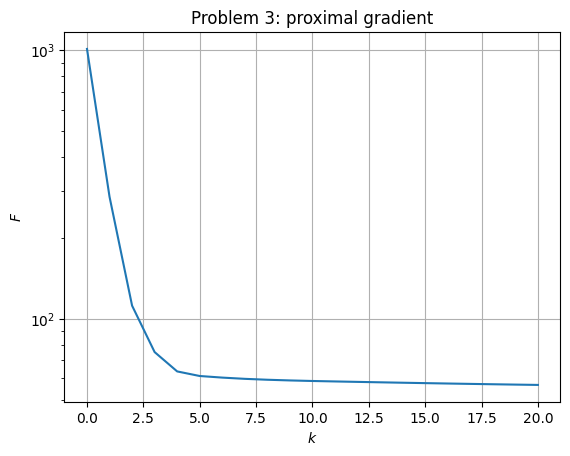

In [ ]:
np.random.seed(0)
from problem3 import *

def prox_g(x, tau):
    nrm = np.linalg.norm(x)
    if nrm <= epsilon:
        return np.copy(x)
    if nrm - epsilon <= tau:
        return epsilon*x/nrm
    return (1 - tau/nrm)*x

def prox_grad(F, grad_f, prox_g, x_init, tau, iterMax, prec):
    x = np.copy(x_init)
    x_tab = np.copy(x)
    epsilon = prec

    print("\nProximal gradient\n \nSTART")

    for k in range(iterMax):
        x_new = prox_g(x - tau*grad_f(x), tau)
        x_tab = np.vstack((x_tab, x_new))
        if np.linalg.norm(x_new - x) < epsilon:
            x = x_new
            break
        x = x_new

    print("FINISHED -- {:d} iterations -- final value: {:f}\n\n".format(k, F(x)))

    return x, x_tab

K = 20
x_init = np.zeros(d)
runs = {}

for tau in [0.25, 0.5]:
    x, x_tab = prox_grad(F, grad_f, prox_g, x_init, tau, K, 1e-8)
    runs[tau] = (x, x_tab)
    print('tau =', tau, 'F =', F(x), 'f =', f(x), 'g =', g(x))

tau = 0.5
x, x_tab = runs[tau]
print('selected tau =', tau)
print('final F =', F(x))
print('final f =', f(x))
print('final g =', g(x))
print('||x|| =', np.linalg.norm(x), 'epsilon =', epsilon)

plt.figure()
plt.semilogy([F(u) for u in x_tab])
plt.xlabel(r'$k$')
plt.ylabel(r'$F$')
plt.title(r'Problem 3: proximal gradient')
plt.grid(True)
plt.show()

Since $f$ is smooth convex and $g$ is convex with an explicit proximal operator, proximal gradient is the natural first-order method. Here $\nabla f$ is separable and each diagonal Hessian entry is bounded by $2$, so $L \le 2$ and the standard step $\tau = 1/L = 0.5$ is theoretically justified.

### Problem 4

Find a point that belongs to $C_1 \cap C_2 \cap C_3$, where $C_i = \{ x \in \mathbb{R}^d,\,a_i^\top x \leq b_i\}$ and
$$
\textrm{proj}_{C_i}(x) = x + \frac{\min \{0, b_i - a_i^\top x \}}{\|a_i\|_2^2} a_i
$$
for $i \in \{1,2\}$, and where $C_3 = \{x \in \mathbb{R}^d,\, x\top x \leq 1 \}$ with
$$
\textrm{proj}_{C_3}(x) = \frac{1}{\max \{ 1, \| x \| \}} x.
$$
You have access to the vectors $a_1, a_2 \in \mathbb{R}^d$ and to the scalars $b_1, b_2 \in \mathbb{R}$.

In [65]:
np.random.seed(0)
from problem4 import *

def proj_halfspace(x, a, b):
    return x + min(0.0, b - np.inner(a, x))*a/np.inner(a, a)

def proj_ball(x):
    return x / max(1.0, np.linalg.norm(x))

def proj(x):
    return proj_ball(proj_halfspace(proj_halfspace(x, a1, b1), a2, b2))

x_init = np.zeros(d)
print('0 in C1 =', np.inner(a1, x_init) <= b1)
print('0 in C2 =', np.inner(a2, x_init) <= b2)
print('0 in C3 =', np.linalg.norm(x_init) <= 1.0)

x, x_tab = POCS(proj, x_init, 5)
print('final point =', x)
print('constraint residuals =', max(np.inner(a1, x) - b1, 0.0), max(np.inner(a2, x) - b2, 0.0), max(np.linalg.norm(x) - 1.0, 0.0))

0 in C1 = True
0 in C2 = True
0 in C3 = True
------------------------------------
 POCS 
------------------------------------
START
FINISHED -- 4 iterations -- 0.000507s 


final point = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
constraint residuals = 0.0 0.0 0.0


This is a pure feasibility problem with explicit projections onto each set, so POCS is the right algorithm. However, $x_0=0$ is already feasible because $b_1,b_2 \geq 0$ . Indeed, $b_1$ and $b_2$ are generated via `np.random.rand()` which returns scalars in $[0,1)$. Obviously, $0 \in C_3$, so the problem is solved immediately from the required starting point.

### Problem 5

Minimize the function $f : \mathbb{R}^d \rightarrow \mathbb{R}$ defined by $f(x) = c^\top x$, where $c \in \mathbb{R}^d$, over the set $C = \{ x \in \mathbb{R}^d,\, \| x \|_2 \leq 1 \}$, which coincides with the set $C_3$ from Problem 4. You can use the oracles `f` and `grad_f` which can be used to evaluate (exactly) $f$ and $\nabla f$.

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 1 iterations -- 0.000131s -- final value: 0.000000 -- final gradient norm: 14.479122 


tau = 0.06906496082020576
f(x) = 1.7763568394002505e-15
||x - x_star|| = 7.294610193666462e-17
exact minimum = 0


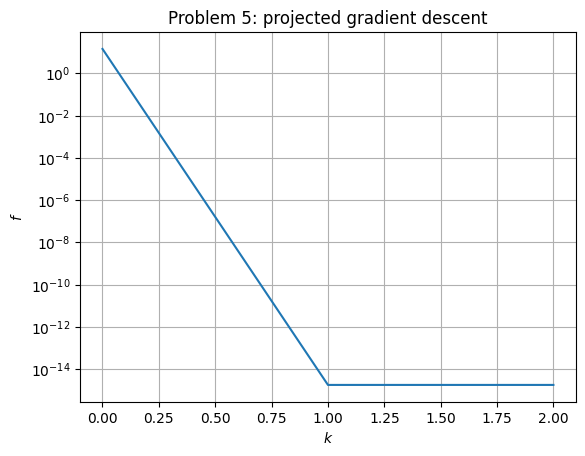

In [60]:
np.random.seed(0)
from problem5 import *

def proj_ball(x):
    return x / max(1.0, np.linalg.norm(x))

x_init = np.zeros(d)
tau = 1.0 / np.linalg.norm(c)
x, x_tab = proj_GD(f, grad_f, proj_ball, x_init, tau, 10, 1e-12)
x_star = -c / np.linalg.norm(c)

print('tau =', tau)
print('f(x) =', f(x))
print('||x - x_star|| =', np.linalg.norm(x - x_star))
print('exact minimum = 0')

plt.figure()
plt.semilogy([max(f(u), 1e-16) for u in x_tab])
plt.xlabel(r'$k$')
plt.ylabel(r'$f$')
plt.title(r'Problem 5: projected gradient descent')
plt.grid(True)
plt.show()

This is a convex constrained smooth problem with an easy projection onto the Euclidean ball, so projected gradient descent is natural. By Cauchy-Schwarz, $c^\top x \ge -\|c\|_2$ on $\|x\|_2 \le 1$, hence $f(x)=c^\top x + \|c\|_2 \ge 0$ with equality at $x_*=-c/\|c\|_2$. From $x_0=0$, projected GD with $\tau = 1/\|c\|_2$ reaches $x_*$ in one projection.